This notebook contains the source code for the project's visualizations. For comprehensive analysis and explanations, please refer to the **Final Report (Special Projects in Econ Research - Unemployment and Crime.pdf).**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# US Unemployment

In [2]:
unemp= pd.read_csv("Data/Unemployement.csv").iloc[:,3:]
unemp["Label"]= pd.to_datetime(unemp["Label"])
unemp= unemp.set_index("Label")
unemp

,Value
Label,
2006-01-01,4.7
2006-02-01,4.8
2006-03-01,4.7
2006-04-01,4.7
2006-05-01,4.6
...,...
2016-08-01,4.9
2016-09-01,5.0
2016-10-01,4.9


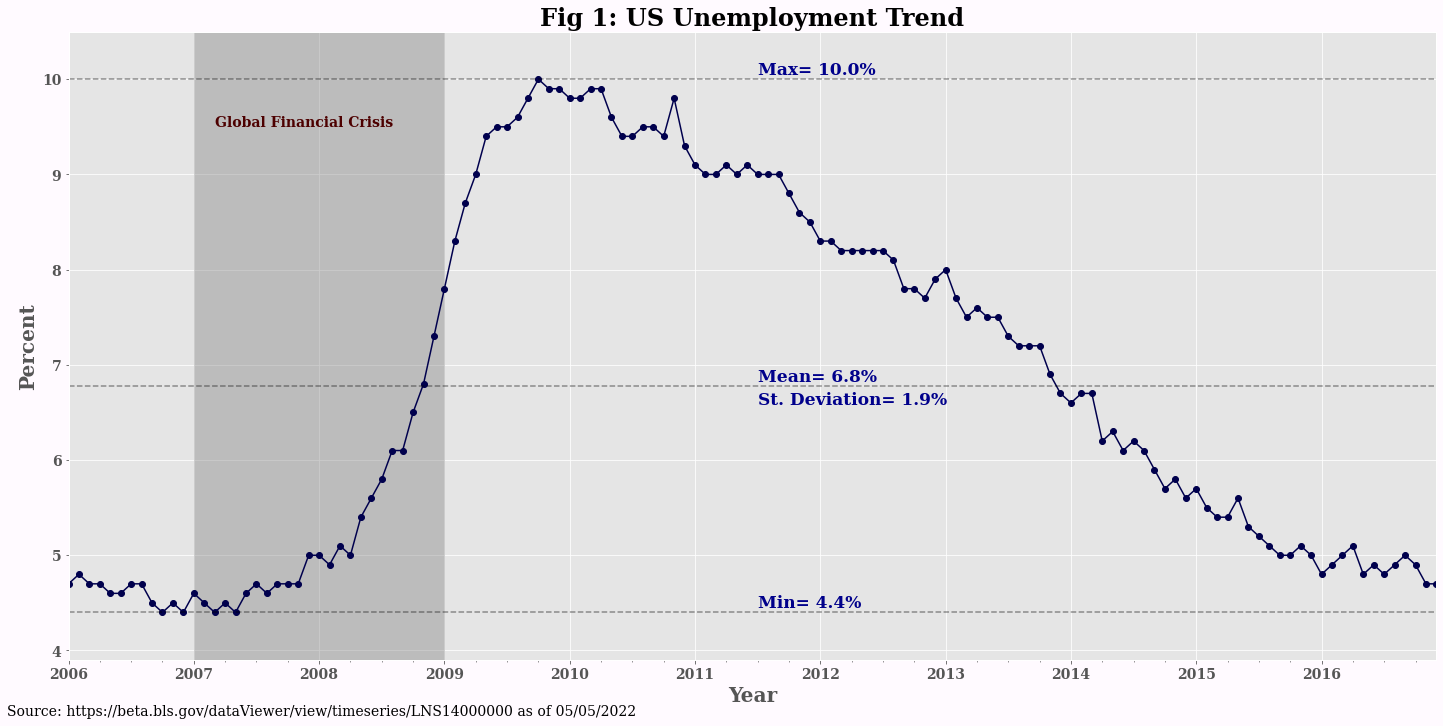

In [3]:
fig,ax= plt.subplots(ncols=1,nrows=1, figsize=(20,10))
unemp.plot(ax=ax, color=(0,0,0.3,1), marker='o', legend=False)


for i in [min,np.mean,max]:
    ax.axhline(y=unemp["Value"].agg(i),color=(0,0,0,0.4), linestyle='--')
    ax.text(
    ax.get_xticks()[5]+6,unemp["Value"].agg(i)+0.05,
    i.__name__.capitalize()+"= "+str(np.round(unemp["Value"].agg(i),1))+"%",
    color='darkblue',fontsize=17,family='serif',fontweight='bold')

ax.text(
    ax.get_xticks()[5]+6,unemp["Value"].mean()-0.2,"St. Deviation= "+str(np.round(unemp["Value"].std(),1))+"%",
    color='darkblue',fontsize=17,family='serif',fontweight='bold')

ax.set_title("Fig 1: US Unemployment Trend",fontsize=24,fontweight="bold",family='serif')

ax.set_ylabel("Percent",fontsize=20,family='serif',fontweight='bold')
ax.set_ylim([3.9,10.5])
ax.set_yticks(range(4,11))
ax.set_yticklabels(range(4,11),fontsize=14,family='serif',fontweight='bold')

ax.axvspan(ax.get_xticks()[1], ax.get_xticks()[3], color="grey", alpha=0.4)
ax.text(ax.get_xticks()[1]+2,9.5,"Global Financial Crisis",color=(0.3,0,0,1),fontsize=14,family='serif',fontweight='bold')

ax.set_xlabel("Year",fontsize=20,family='serif',fontweight='bold')
ax.set_xticklabels(range(2006,2017),fontsize=14,family='serif',fontweight='bold')
fig.set_facecolor(tuple(np.array([255, 250, 255]) / 255))

fig.tight_layout()
fig.text(0,0,"Source: https://beta.bls.gov/dataViewer/view/timeseries/LNS14000000 as of 05/05/2022", fontsize=14,family='serif')


fig.savefig('Figures/US_unemp.jpg',bbox_inches='tight')

# US Crime Trend

In [4]:
crime= pd.read_excel("Data/Crime_data.xls").iloc[9:20,[0,15,3]].astype('float')
crime.columns=["Year","Property Crime","Violent Crime"]
crime= crime.set_index("Year")
crime

,Property Crime,Violent Crime
Year,,
2006.0,3346.6,479.3
2007.0,3276.4,471.8
2008.0,3214.6,458.6
2009.0,3041.3,431.9
2010.0,2945.9,404.5
2011.0,2905.4,387.1
2012.0,2868.0,387.8
2013.0,2733.6,369.1
2014.0,2574.1,361.6


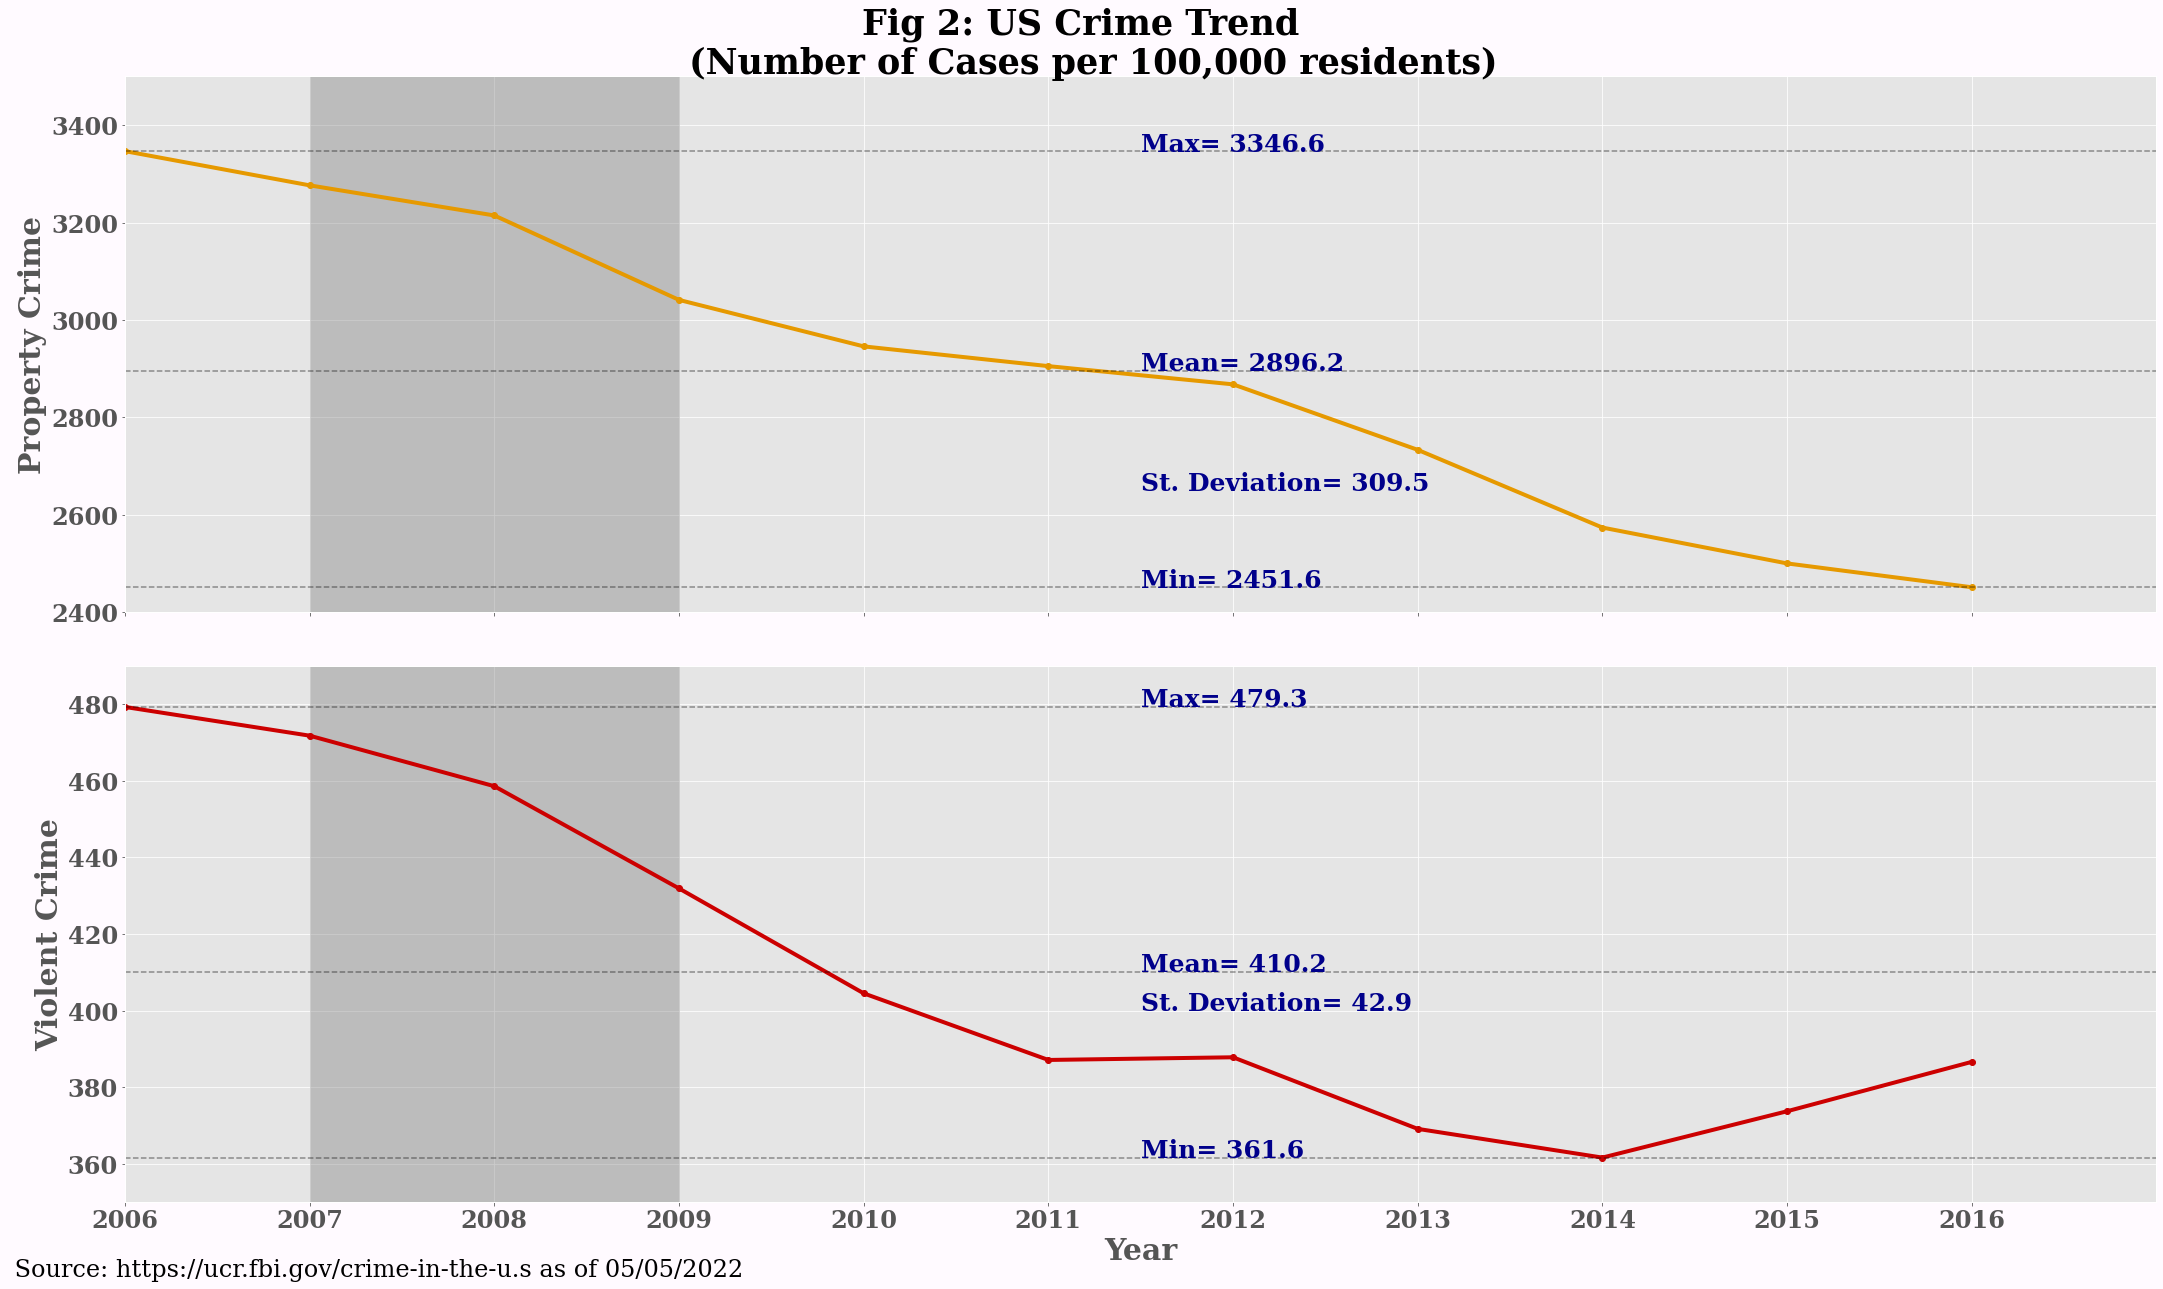

In [5]:
fig,ax= plt.subplots(ncols=1,nrows=2, figsize=(30,18), sharex=True)
col= [(0.9,0.6,0),(0.8,0,0,1)]
c=0
for i in crime.columns:
    crime.loc[:,i].plot(ax=ax[c], color=col[c], linewidth=4,marker='o')
    ax[c].set_ylabel(i,fontsize=30,family='serif',fontweight='bold')

    for j in [min,np.mean,max]:
        ax[c].axhline(y=crime[i].agg(j),color=(0,0,0,0.4), linestyle='--')
        ax[c].text(
            2011.5,crime[i].agg(j),
            j.__name__.capitalize()+"= "+str(np.round(crime[i].agg(j),1)),
            color='darkblue',fontsize=25,family='serif',fontweight='bold')

    ax[c].axvspan(2007, 2009, color="grey", alpha=0.4)
    c+=1

ax[0].text(
        2011.5,2650,"St. Deviation= "+str(np.round(crime["Property Crime"].std(),1)),
        color='darkblue',fontsize=25,family='serif',fontweight='bold')

ax[1].text(
        2011.5,400,"St. Deviation= "+str(np.round(crime["Violent Crime"].std(),1)),
        color='darkblue',fontsize=25,family='serif',fontweight='bold')

ax[0].set_ylim([2400,3500])
ax[0].set_yticks(range(2400,3600,200))
ax[0].set_yticklabels(range(2400,3600,200),fontsize=24,family='serif',fontweight='bold')

ax[1].set_xlabel("Year",fontsize=30,family='serif',fontweight='bold')
ax[1].set_xlim([2006,2017])
ax[1].set_xticks(range(2006,2017))
ax[1].set_xticklabels(range(2006,2017),fontsize=24,family='serif',fontweight='bold')

ax[1].set_ylim([350,490])
ax[1].set_yticks(range(360,500,20))
ax[1].set_yticklabels(range(360,500,20),fontsize=24,family='serif',fontweight='bold')


fig.suptitle("Fig 2: US Crime Trend \n (Number of Cases per 100,000 residents)",fontsize=35,fontweight="bold",family='serif')
fig.set_facecolor(tuple(np.array([255, 250, 255]) / 255))

fig.tight_layout()
fig.subplots_adjust(hspace=0.1)

fig.text(0,0,"\n\n Source: https://ucr.fbi.gov/crime-in-the-u.s as of 05/05/2022", fontsize=24,family='serif')
fig.savefig('Figures/US_trend.jpg',bbox_inches='tight')


# Male Variables Visualiztion

In [6]:
data_gender= pd.read_excel("Data/Gender_data.xls").iloc[[3,14,15],[0,4,5]]

data_gender.iloc[0]= data_gender.iloc[0].str.replace("Percent\n","").str.capitalize()

data_gender=data_gender.T.reset_index().drop(columns=["index"])

data_gender.columns= ["Arrests by gender", "Violent crime","Property crime"]
data_gender= data_gender.drop(0).set_index("Arrests by gender")
data_gender

,Violent crime,Property crime
Arrests by gender,,
Male,78.9,62.3
Female,21.1,37.7


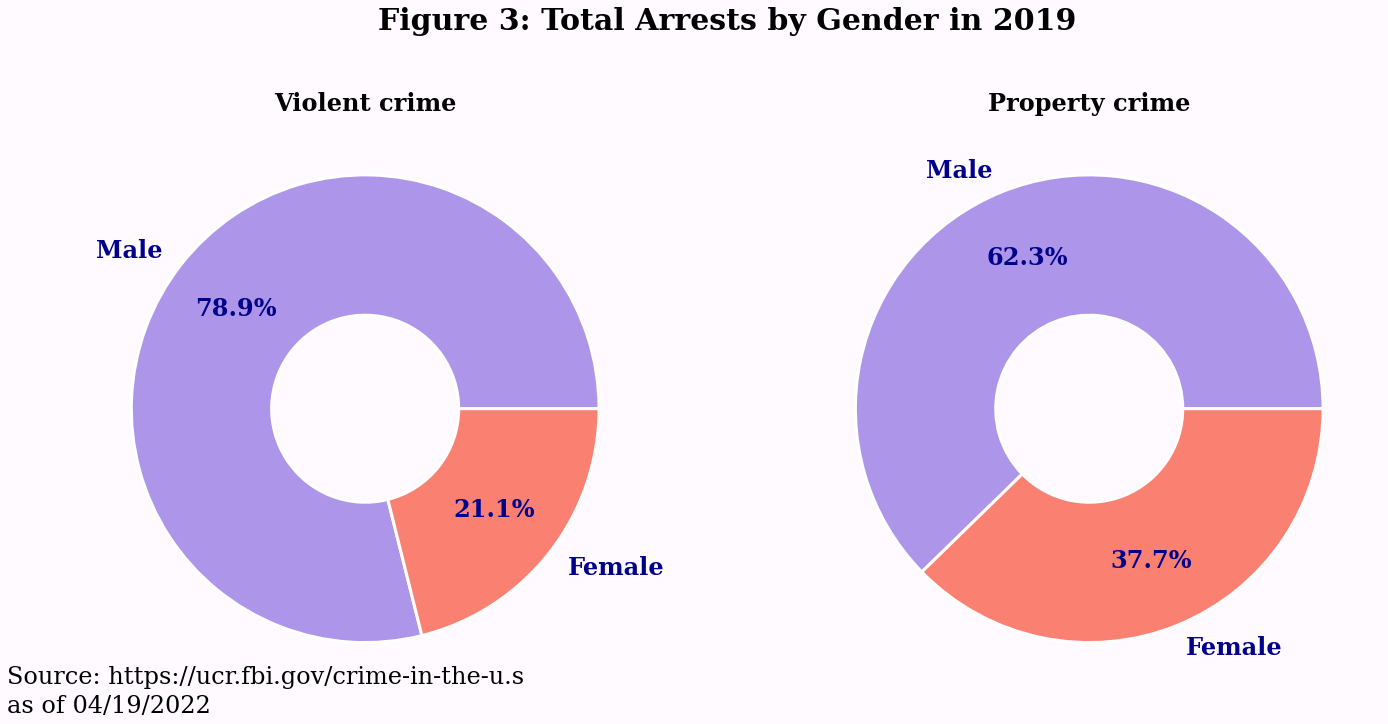

In [7]:


fig,ax= plt.subplots(ncols=2,nrows=1, figsize=(20,10))

c=0
for i in data_gender.columns.to_list():
    data_gender[i].plot.pie(
        ax=ax[c],
        colors=[(0.2,0,0.8,0.4),'salmon'],
        autopct='%1.1f%%',
        textprops={'fontsize': 24, 'color':'darkblue','fontweight':550,'family':'serif'},
        wedgeprops = {'width':0.6, 'linewidth':3, 'edgecolor':(1,1,1,1)},
        pctdistance=0.7)
    ax[c].set_title(i,fontsize=24,fontweight="bold",family='serif')
    ax[c].set_ylabel("")
    c+=1

fig.suptitle("Figure 3: Total Arrests by Gender in 2019\n\n",fontsize=30,fontweight="bold",family='serif')
fig.set_facecolor(tuple(np.array([255, 250, 255]) / 255))
fig.tight_layout()
fig.text(0,0.04,"Source: https://ucr.fbi.gov/crime-in-the-u.s", fontsize=24,family='serif')
fig.text(0,0,"as of 04/19/2022", fontsize=24,family='serif')

fig.savefig('Figures/gender.jpg')

# Male Arrests by Age

In [8]:
male_age= pd.read_excel("Data/Male_age.xls").set_index("Table 39").iloc[[3,14,16],4:26].reset_index()
male_age.iloc[0,1]= "Under 10"
male_age.iloc[0,22]= "65 and above"
male_age.iloc[0,6]= "17"

male_age.columns= male_age.iloc[0]
male_age= male_age.drop(0)


male_age["Under 15"]= male_age.iloc[:,1:4].sum(axis=1)
male_age["15-24"]= male_age.iloc[:,4:14].sum(axis=1)
male_age["25-39"]= male_age.iloc[:,14:17].sum(axis=1)
male_age["Above 39"]=male_age.iloc[:,17:23].sum(axis=1)

male_age= male_age.T.reset_index().iloc[23:]
male_age.columns= ["Arrests by Age", "Violent crime","Property crime"]
male_age= male_age.set_index("Arrests by Age")

male_age

,Violent crime,Property crime
Arrests by Age,,
Under 15,8418.0,18250.0
15-24,80681.0,136881.0
25-39,121087.0,208112.0
Above 39,73281.0,128388.0


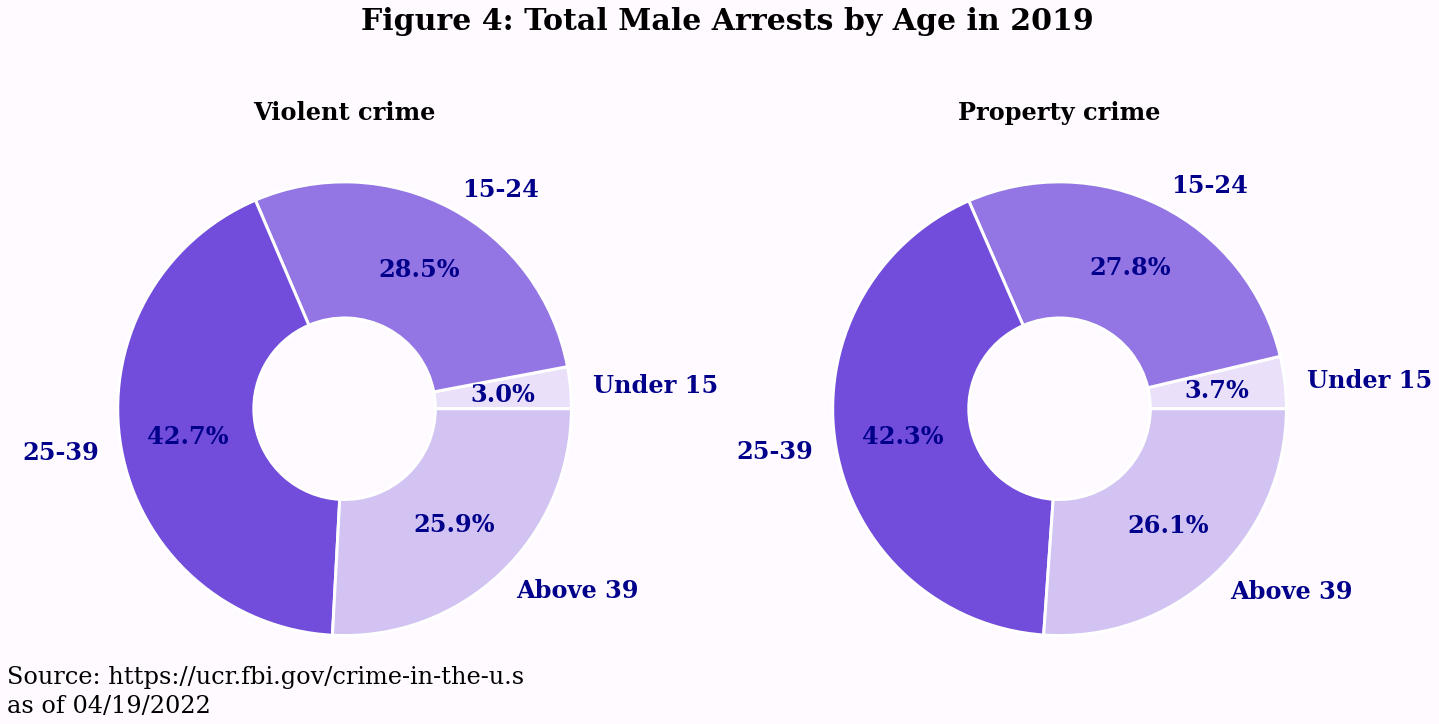

In [9]:
fig,ax= plt.subplots(ncols=2,nrows=1, figsize=(20,10))

c=0


for i in male_age.columns.to_list():
    male_age[i].plot.pie(
        ax=ax[c],
        colors=[(0.2,0,0.8,0.1),(0.2,0,0.8,0.53),(0.2,0,0.8,0.69),(0.2,0,0.8,0.22)],
        autopct='%1.1f%%',
        textprops={'fontsize': 24, 'color':'darkblue','fontweight':550,'family':'serif'},
        wedgeprops = {'width':0.6, 'linewidth':3, 'edgecolor':(1,1,1,1)},
        pctdistance=0.7)
    ax[c].set_title(i,fontsize=24,fontweight="bold",family='serif')
    ax[c].set_ylabel("")
    c+=1

fig.suptitle("Figure 4: Total Male Arrests by Age in 2019\n\n",fontsize=30,fontweight="bold",family='serif')
fig.set_facecolor(tuple(np.array([255, 250, 255]) / 255))
fig.tight_layout()

fig.text(0,0.04,"Source: https://ucr.fbi.gov/crime-in-the-u.s", fontsize=24,family='serif')
fig.text(0,0,"as of 04/19/2022", fontsize=24,family='serif')

fig.savefig('Figures/Male_Arrests_Age.jpg')


# California unemployment rank

In [10]:
states = pd.read_csv("Data/Special Project Research Final Data - State_long .csv")
states["year"]= states["year"].astype(int)
states["unemployment"]= states["unemployment"].astype(float)
states= states.loc[~states["state"].isin(['Puerto rico','District of Columbia','district of Columbia']),:]


def assign_rank(Year):
    df= states.query("year== @Year").set_index("state")
    rank= df.sort_values("unemployment", ascending=False).rank(method='min').loc["California","unemployment"].astype(int)
    position= str(50-rank+1)
    if position=="16":
        position= position+'th'
    elif position=="3":
        position= " "+position+'rd'
    else:
        position= " "+position+'th'
    rank= pd.DataFrame({'Rank':rank,'Position':position},index=[Year])
    return rank
    
u_ranks= assign_rank(2006)
for i in range(2007,2017):
    u_ranks= pd.concat([u_ranks,assign_rank(i)])

u_ranks


,Rank,Position
2006,35,16th
2007,44,7th
2008,47,4th
2009,46,5th
2010,48,3rd
2011,48,3rd
2012,48,3rd
2013,47,4th
2014,47,4th
2015,44,7th


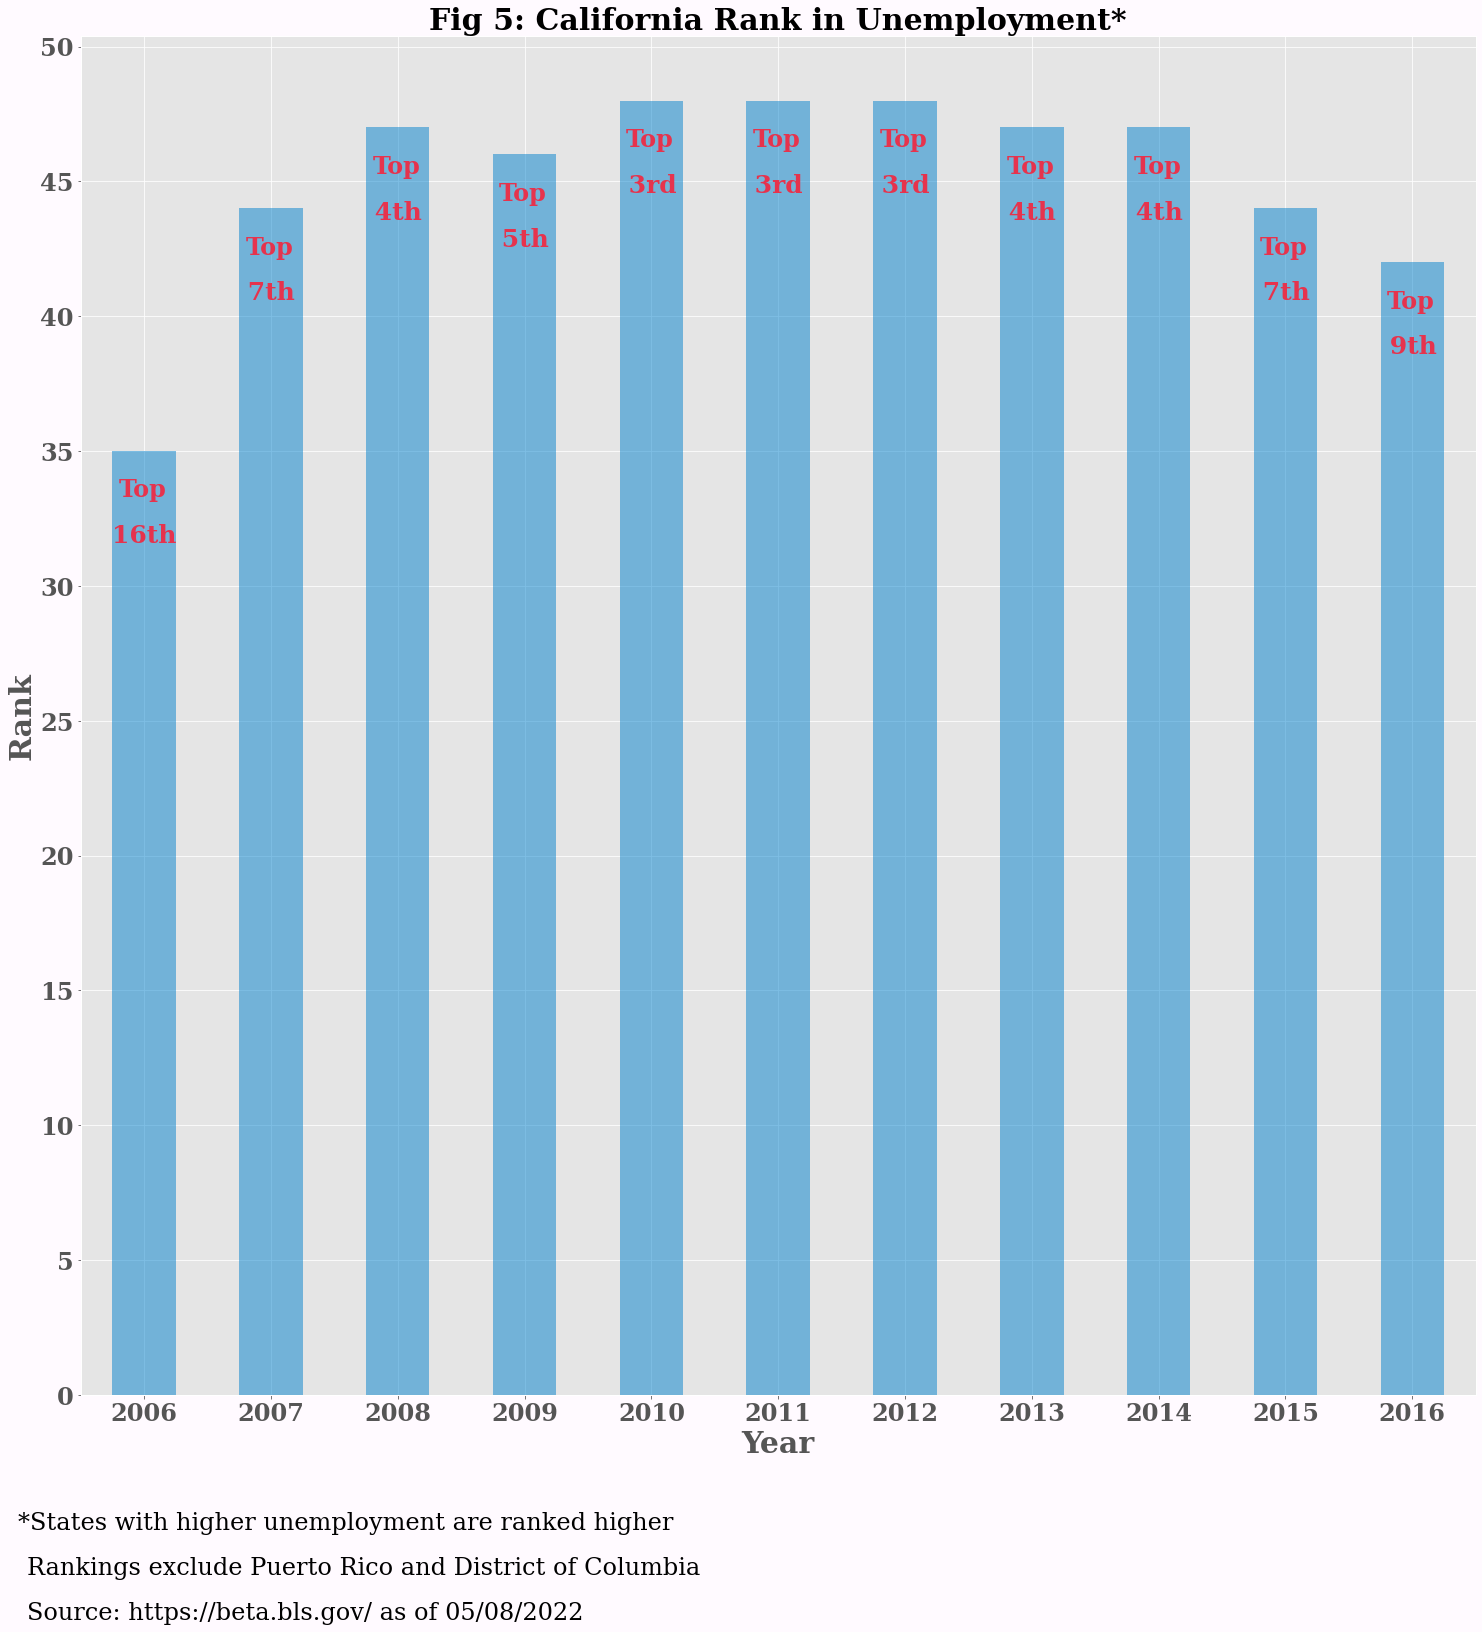

In [11]:
fig,ax= plt.subplots(figsize=(25,25))

u_ranks["Rank"].plot(ax=ax,kind='bar',color=(0,0.5,0.8,0.5))

for i in range(0,11):
    ax.text(
        i-0.2,u_ranks.loc[i+2006,"Rank"]-1.7,"Top",
        fontsize=24,family='serif',fontweight='bold',color=(0.9,0.2,0.3))

    ax.text(
        i-0.25,(u_ranks.loc[i+2006,"Rank"])-3.4,u_ranks.loc[i+2006,"Position"],
        fontsize=25,family='serif',fontweight='bold',color=(0.9,0.2,0.3)) 

ax.set_ylabel("Rank",fontsize=30,family='serif',fontweight='bold')
ax.set_yticks(range(0,55,5))
ax.set_yticklabels(range(0,55,5),fontsize=24,family='serif',fontweight='bold')

ax.set_xlabel("Year",fontsize=30,family='serif',fontweight='bold')
ax.set_xticklabels(range(2006,2017),fontsize=24,family='serif',fontweight='bold', rotation=0)

ax.set_title("Fig 5: California Rank in Unemployment*",fontsize=30,fontweight="bold",family='serif')
fig.set_facecolor(tuple(np.array([255, 250, 255]) / 255))

fig.text(0.09,0.05,"*States with higher unemployment are ranked higher", fontsize=24,family='serif')
fig.text(0.095,0.025,"Rankings exclude Puerto Rico and District of Columbia", fontsize=24,family='serif')
fig.text(0.095,0,"Source: https://beta.bls.gov/ as of 05/08/2022", fontsize=24,family='serif')

fig.savefig('Figures/Cali_ranks.jpg',bbox_inches='tight')

# Crime concern

In [12]:
concern= pd.DataFrame(
    {'California Average':[51,46,54],
    'National Average':[38,42,41]},
    index=['Gun Violence','Property Crime','Violent Crime']
    )
concern


,California Average,National Average
Gun Violence,51,38
Property Crime,46,42
Violent Crime,54,41


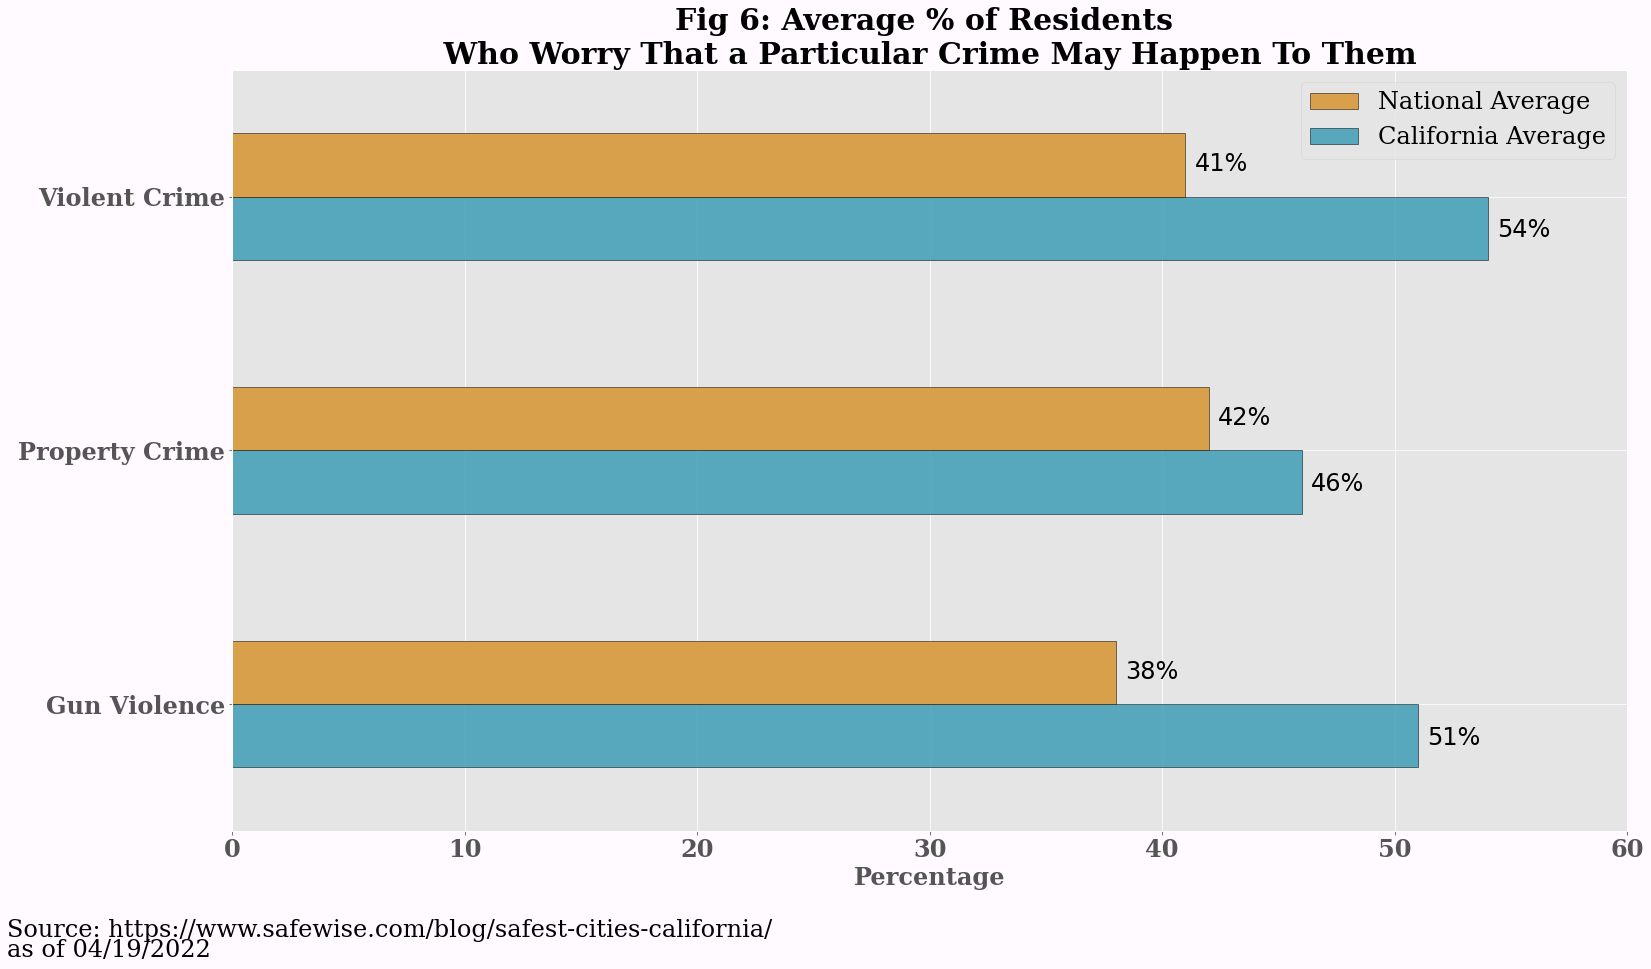

In [13]:
fig,ax= plt.subplots(ncols=1,nrows=1, figsize=(25,14))
colors= [(0.2,0.5976,0.7,0.8),(0.85,0.629,0.2975)]

concern.plot.barh(
    ax=ax,
    color=colors,
    edgecolor='k',
    label=True,
    fontsize=20)

#Customize order of labels in legend
handles, labels = ax.get_legend_handles_labels()

#specify order of items in legend
order = [1,0]

#add legend to plot
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc='upper right', prop={'size':24,'family':'serif'})
ax.set_xlim([0,60])
ax.set_xlabel("Percentage",fontsize=24,family='serif',fontweight='bold')
ax.set_yticklabels(concern.index,fontsize=24,family='serif',fontweight='bold')
ax.set_xticklabels(range(0,70,10),fontsize=24,family='serif',fontweight='bold')

s=0
for i in concern.index:
    ax.text(concern.loc[i,"National Average"]+0.4,s+0.1,str(concern.loc[i,"National Average"])+'%',fontsize=24)
    ax.text(concern.loc[i,"California Average"]+0.4,s-0.16,str(concern.loc[i,"California Average"])+'%',fontsize=24)
    s+=1

ax.set_title("Fig 6: Average % of Residents \n Who Worry That a Particular Crime May Happen To Them ",fontsize=30,fontweight="bold",family='serif')
fig.set_facecolor(tuple(np.array([255, 250, 255]) / 255))

fig.text(0,0.02,"Source: https://www.safewise.com/blog/safest-cities-california/", fontsize=24,family='serif')
fig.text(0,0,"as of 04/19/2022", fontsize=24,family='serif')


fig.savefig('Figures/crime_concern.jpg',bbox_inches='tight')


# LA Country Crime Trend

In [14]:
la= pd.read_csv("Data/California County_data.csv")
la= la.query("county=='Los Angeles County'").loc[:,['year','property crime rate per 1000 persons','violent crime rate per 1000 persons']].astype('float').set_index('year')
la.columns= ["Property Crime", "Violent Crime"]
la


,Property Crime,Violent Crime
year,,
2012.0,23.343800,4.47808
2013.0,22.794945,4.03010
2014.0,21.558597,4.23504
2015.0,23.651036,4.97219
2016.0,24.776013,5.53537
2017.0,24.309199,5.85695


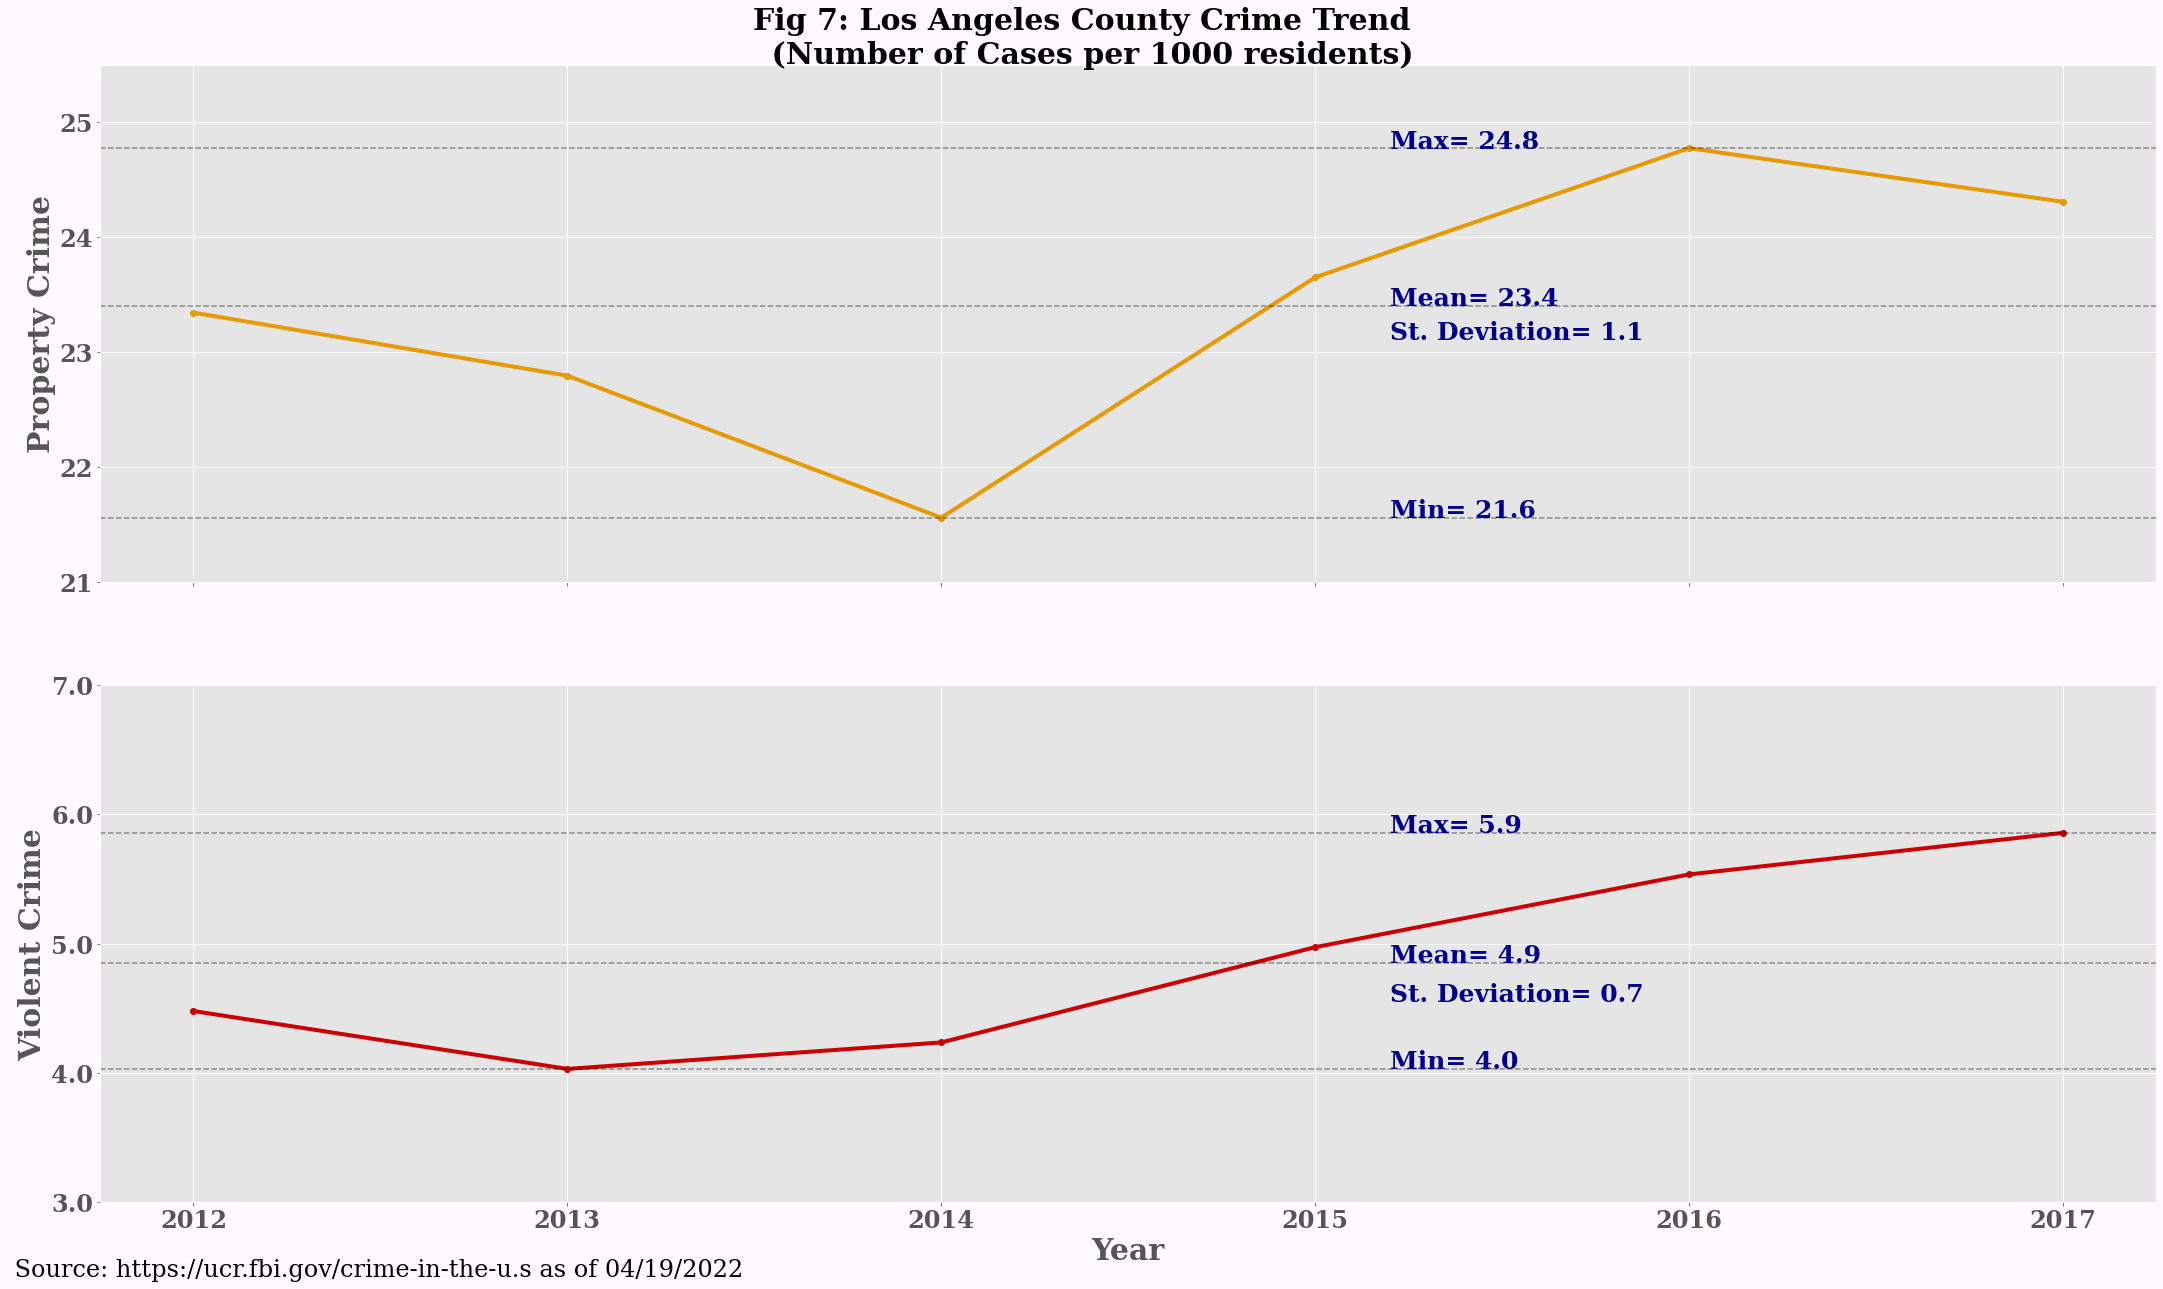

In [15]:
fig,ax= plt.subplots(ncols=1,nrows=2, figsize=(30,18), sharex=True)
col= [(0.9,0.6,0),(0.8,0,0,1)]
c=0
for i in la.columns:
    la.loc[:,i].plot(ax=ax[c], color=col[c], linewidth=4,marker='o')
    ax[c].set_ylabel(i,fontsize=30,family='serif',fontweight='bold')

    for j in [min,np.mean,max]:
        ax[c].axhline(y=la[i].agg(j),color=(0,0,0,0.4), linestyle='--')
        ax[c].text(
            2015.2,la[i].agg(j),
            j.__name__.capitalize()+"= "+str(np.round(la[i].agg(j),1)),
            color='darkblue',fontsize=25,family='serif',fontweight='bold')
    ax[c].text(
         2015.2,la[i].mean()-0.3,"St. Deviation= "+str(np.round(la[i].std(),1)),
        color='darkblue',fontsize=25,family='serif',fontweight='bold')
    c+=1


ax[0].set_ylim([21,25.5])
ax[0].set_yticks([21,22,23,24,25])
ax[0].set_yticklabels([21,22,23,24,25],fontsize=24,family='serif',fontweight='bold')

ax[1].set_xlabel("Year",fontsize=30,family='serif',fontweight='bold')
ax[1].set_xticklabels(range(2011,2018),fontsize=24,family='serif',fontweight='bold')

ax[1].set_yticks([3.00,4.00,5.00,6.00,7.00])
ax[1].set_yticklabels([3.00,4.00,5.00,6.00,7.00],fontsize=24,family='serif',fontweight='bold')



fig.suptitle("Fig 7: Los Angeles County Crime Trend \n (Number of Cases per 1000 residents)",fontsize=30,fontweight="bold",family='serif')
fig.set_facecolor(tuple(np.array([255, 250, 255]) / 255))

fig.tight_layout()
fig.subplots_adjust(hspace=0.2)

fig.text(0,0,"\n\n Source: https://ucr.fbi.gov/crime-in-the-u.s as of 04/19/2022", fontsize=24,family='serif')
fig.savefig('Figures/la_trend.jpg',bbox_inches='tight')